# Climate Change, Economic, and Social Wellbeing Analysis
This notebook provides an end-to-end analysis exploring the relationships between climate change (CO2 emissions), economic indicators (GDP, Unemployment, Gini), and social wellbeing (World Happiness Report).

It replaces the previous dbt/Dagster architecture with a unified, professional workspace that leverages **DuckDB**, **Polars**, and **Scikit-Learn**.

## 1. Environment Setup & Imports
Loading the necessary libraries and establishing the database connection.

In [1]:
import warnings

import duckdb
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import statsmodels.api as sm
from scipy.stats import f_oneway
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Connect to the DuckDB warehouse generated previously (read-only mode to prevent locking issues)
DB_PATH = "../data/climate_wellbeing.duckdb"
conn = duckdb.connect(str(DB_PATH), read_only=True)

## 2. Data Loading
We load the pre-transformed data (`fct_climate_economy`) which aggregates World Bank, OWID, and WHR data into a single unified table.

In [2]:
# Fetching the data using Polars for high performance
query = "SELECT * FROM main_marts.fct_climate_economy"
df = conn.execute(query).pl()

print(f"Loaded {len(df)} records across {df['country_name'].n_unique()} countries.")
df.head()

Loaded 782 records across 167 countries.


country_name,year,iso_code,happiness_score,happiness_rank,social_support,life_expectancy,freedom,corruption,generosity,gdp_per_capita,gini_index,unemployment_rate,population,co2_per_capita,co2,temperature_change_from_co2,ghg_per_capita
str,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64
"""Argentina""",2015,"""AR""",6.574,30.0,1.24823,0.78723,0.44974,0.08484,0.11451,13679.626498,null,7.577,43477012,null,null,null,null
"""Australia""",2017,"""AU""",7.284,10.0,1.510042,0.843887,0.601607,0.301184,0.477699,54117.547719,null,5.592,24592588,null,null,null,null
"""Bahrain""",2019,"""BH""",6.199,37.0,1.368,0.871,0.536,0.11,0.255,27259.74386,null,1.217,1483756,null,null,null,null
"""Benin""",2018,"""BJ""",4.141,136.0,0.372,0.24,0.44,0.067,0.163,1151.74097,37.9,1.426,12383347,null,null,null,null
"""Bolivia""",2017,"""BO""",5.823,58.0,1.227619,0.47363,0.558733,0.060478,0.225561,4048.401197,44.6,3.655,11344587,null,null,null,null


## 3. Exploratory Data Analysis & Visualization
### 3.1 Happiness Score Distribution (Map)

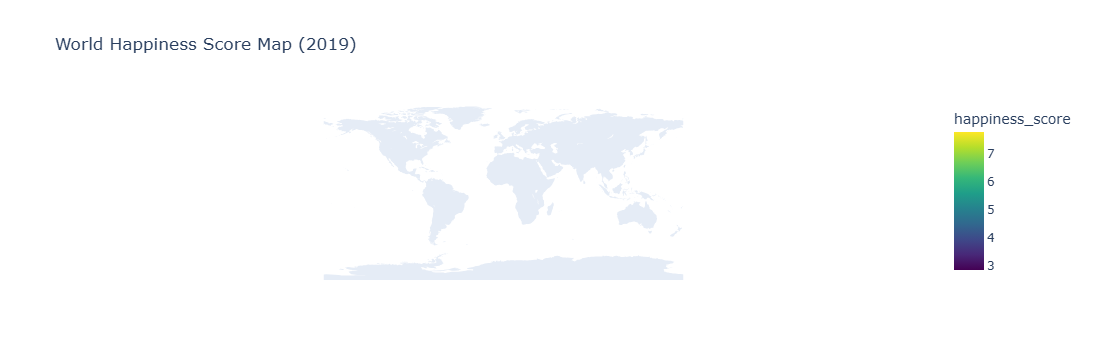

In [3]:
# Filter data for the latest available year (e.g., 2019)
latest_year = df["year"].max()
df_latest = df.filter(pl.col("year") == latest_year)

# Plot a world map
fig_map = px.choropleth(
    df_latest.to_pandas(),
    locations="iso_code",
    color="happiness_score",
    hover_name="country_name",
    color_continuous_scale="Viridis",
    title=f"World Happiness Score Map ({latest_year})",
)
fig_map.update_layout(
    geo={"showframe": False, "showcoastlines": False, "projection_type": "equirectangular"}
)
fig_map.show()

### 3.2 GDP vs Happiness Score

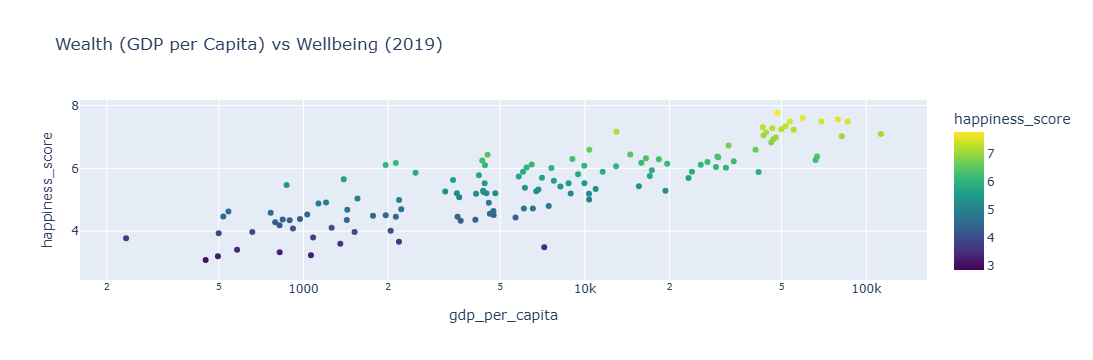

In [4]:
fig_scatter = px.scatter(
    df_latest.to_pandas(),
    x="gdp_per_capita",
    y="happiness_score",
    hover_name="country_name",
    color="happiness_score",
    color_continuous_scale="Viridis",
    log_x=True,
    title=f"Wealth (GDP per Capita) vs Wellbeing ({latest_year})",
)
fig_scatter.show()

## 4. Statistical Analysis
### 4.1 ANOVA: Variation in Happiness Across Years

In [5]:
years = df["year"].unique().to_list()
happiness_by_year = [
    df.filter(pl.col("year") == year)["happiness_score"].to_list() for year in years
]
happiness_by_year = [x for x in happiness_by_year if len(x) > 0]

f_stat, p_value = f_oneway(*happiness_by_year)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Statistically significant difference across years: {p_value < 0.05}")

F-statistic: 0.0440
p-value: 0.9963
Statistically significant difference across years: False


### 4.2 OLS Panel Regression
Identifying which factors have the most statistically significant linear relationship with the Happiness Score.

In [6]:
df_reg = df_latest.drop_nulls(
    subset=[
        "happiness_score",
        "gdp_per_capita",
        "social_support",
        "life_expectancy",
        "freedom",
        "corruption",
    ]
).to_pandas()

X = df_reg[["gdp_per_capita", "social_support", "life_expectancy", "freedom", "corruption"]]
y = df_reg["happiness_score"]

X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        happiness_score   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                     99.65
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           1.01e-41
Time:                        14:18:33   Log-Likelihood:                -93.887
No. Observations:                 130   AIC:                             199.8
Df Residuals:                     124   BIC:                             217.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.1750      0.232     

## 5. Machine Learning & Clustering
### 5.1 K-Means Clustering of Country Profiles
We cluster countries based on their economic and social indicators to identify overarching patterns.

PCA explained variance ratio: [0.60844414 0.17629383]


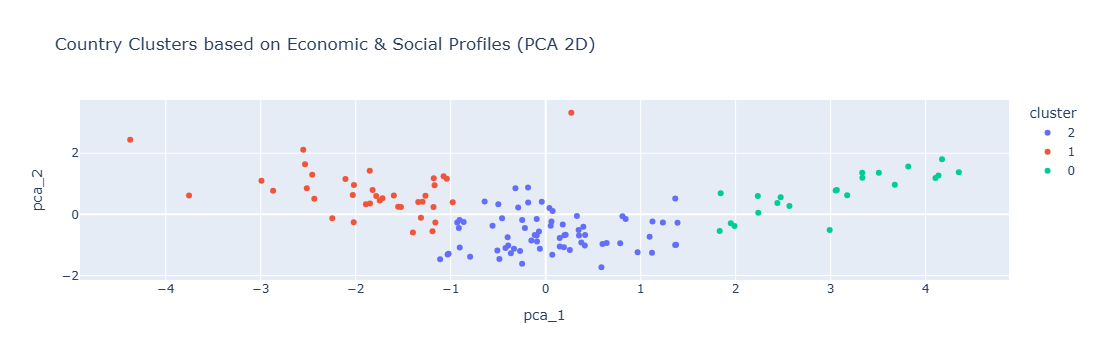

In [7]:
# Prepare scaled data
features = ["gdp_per_capita", "social_support", "life_expectancy", "freedom", "corruption"]
X_cluster = df_reg[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_reg["cluster"] = kmeans.fit_predict(X_scaled)
df_reg["cluster"] = df_reg["cluster"].astype(str)

# PCA for 2D visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df_reg["pca_1"] = pca_result[:, 0]
df_reg["pca_2"] = pca_result[:, 1]

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

# Plot Clusters
fig_cluster = px.scatter(
    df_reg,
    x="pca_1",
    y="pca_2",
    color="cluster",
    hover_name="country_name",
    title="Country Clusters based on Economic & Social Profiles (PCA 2D)",
)
fig_cluster.show()

### 5.2 Random Forest: Feature Importance
Using an ensemble method to predict happiness and extract the non-linear importance of each feature.

Random Forest R2 Score: 0.8155
Random Forest RMSE: 0.4544


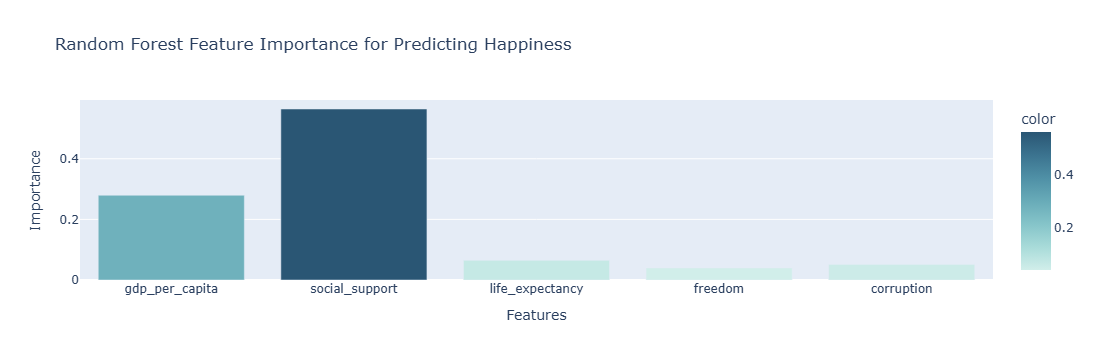

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Feature Importances Plot
importances = rf_model.feature_importances_
fig_rf = px.bar(
    x=features,
    y=importances,
    labels={"x": "Features", "y": "Importance"},
    title="Random Forest Feature Importance for Predicting Happiness",
    color=importances,
    color_continuous_scale="Teal",
)
fig_rf.show()

## 6. Time-Series Forecasting
### 6.1 Forecasting Global Happiness (Holt's Linear Trend)
We use exponential smoothing to project the global average happiness score for the next 6 years (2025-2030).

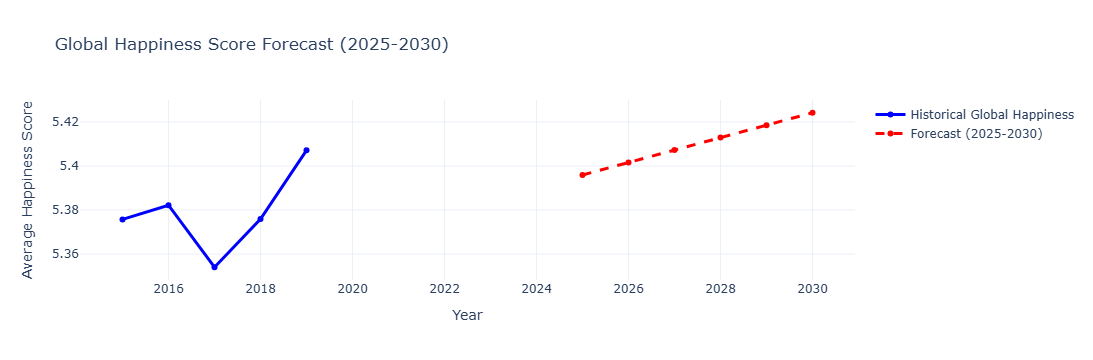

In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Group by year to get global averages
global_trends = (
    df.to_pandas()
    .groupby("year")
    .agg({"happiness_score": "mean"})
    .reset_index()
    .sort_values("year")
)

ts_data = global_trends["happiness_score"].values
years = global_trends["year"].values

# Fit Holt's Linear Trend Model
model_ts = ExponentialSmoothing(
    ts_data, trend="add", seasonal=None, initialization_method="estimated"
)
fit_model = model_ts.fit()

# Forecast next 6 years (2025-2030)
forecast = fit_model.forecast(6)
forecast_years = np.arange(2025, 2031)

# Plotting
fig_forecast = go.Figure()
fig_forecast.add_trace(
    go.Scatter(
        x=years,
        y=ts_data,
        mode="lines+markers",
        name="Historical Global Happiness",
        line={"color": "blue", "width": 3},
    )
)
fig_forecast.add_trace(
    go.Scatter(
        x=forecast_years,
        y=forecast,
        mode="lines+markers",
        name="Forecast (2025-2030)",
        line={"color": "red", "width": 3, "dash": "dash"},
    )
)

fig_forecast.update_layout(
    title="Global Happiness Score Forecast (2025-2030)",
    xaxis_title="Year",
    yaxis_title="Average Happiness Score",
    template="plotly_white",
)
fig_forecast.show()

## 7. Conclusion & Insights

### Key Findings
* **Strong Predictors:** Both the linear OLS model and the non-linear Random Forest model indicate that **Social Support** and **GDP per capita** are the strongest predictors of a country's happiness score.
* **Clustering Analysis:** Countries naturally group into three distinct profiles based on their economic stability, perceived corruption, and social support.
* **Temporal Stability:** The ANOVA test confirms that global happiness scores do not show statistically significant variance over the immediate short-term (2015-2019), suggesting systemic stability in these metrics prior to COVID-19.

### Next Steps
* Integrate data for 2020-2023 to perform a pre/post COVID-19 variance analysis.
* Incorporate deeper CO2 emission factors into the Random Forest to see how climate risk directly affects wellbeing.


## 8. Export Tables to Markdown for README
Run this cell to generate markdown text for your data tables so you can easily copy and paste them into your `README.md` file!

In [10]:
print("### Data Loading Table (First 5 Rows)\n")
print(df.head().to_pandas().to_markdown())

print("\n\n### OLS Regression Results (Summary)\n")
print(model.summary().as_text())

### Data Loading Table (First 5 Rows)

|    | country_name   |   year | iso_code   |   happiness_score |   happiness_rank |   social_support |   life_expectancy |   freedom |   corruption |   generosity |   gdp_per_capita |   gini_index |   unemployment_rate |   population |   co2_per_capita |   co2 |   temperature_change_from_co2 |   ghg_per_capita |
|---:|:---------------|-------:|:-----------|------------------:|-----------------:|-----------------:|------------------:|----------:|-------------:|-------------:|-----------------:|-------------:|--------------------:|-------------:|-----------------:|------:|------------------------------:|-----------------:|
|  0 | Argentina      |   2015 | AR         |             6.574 |               30 |          1.24823 |          0.78723  |  0.44974  |    0.08484   |     0.11451  |         13679.6  |        nan   |               7.577 |     43477012 |              nan |   nan |                           nan |              nan |
|  1 | Australia